# INVERTER CIRCUIT 32nm bulk CMOS

> Dataset source repository: https://github.com/GabriellJacinto/Electrical-Behaviour-Prediction
> Dataset Path: Electrical-Behaviour-Prediction/CMOS/32nm/NOT/Models/simu0/Advanced_Algorithms.ipynb

<small>

I'm using simu_0/treated_data dataset in this analysis

**Joined_data.csv:** contém os resultados brutos das simulações elétricas feitas no hspice (Monte Carlo).

**Treated_data.csv:** contém widths, tensões e temperaturas mapeadas.

O notebook advanced_algorithms usa o joined_data e depois gera o treated_data.

*No entanto, ainda não descobri a diferença entre simulação0 e simulação1. Estou usando a simul0.*

</small>

# Data cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset_path = "/home/eduarda/Repos/jupyter_ic/data/raw/CMOS/32nm/NOT/simu_0/treated_data.txt"
df = pd.read_csv(dataset_path, index_col=0)

Renaming the column 'tensao' to 'voltage' to maintain the English standard

In [3]:
df = df.rename(columns={
    'temper' : 'temperature',
    'tensao' : 'voltage', 
    'pmos@varp': 'PV_pmos', 
    'nmos@var': 'PV_nmos', 
    'width_pmos':  'W PMOS', 
    'width_nmos': 'W NMOS', 
    'length_n&p': 'L',
    'iint' : 'energy'
})

In [4]:
nova_ordem = [
    'PV_nmos',
    'PV_pmos',
    'temperature',
    'voltage',
    'W NMOS',
    'W PMOS',
    'L',
    'tphl', 
    'tplh',
    'energy'
]

df = df[nova_ordem]

df

,PV_nmos,PV_pmos,temperature,voltage,W NMOS,W PMOS,L,tphl,tplh,energy
0,0.5166,-0.4341,-25.0,0.6,7.000000e-08,1.400000e-07,3.200000e-08,9.607000e-12,8.368000e-12,-1.330000e-15
1,0.5064,-0.4523,-25.0,0.6,7.000000e-08,1.400000e-07,3.200000e-08,9.424000e-12,8.791000e-12,-1.337000e-15
2,0.4909,-0.4618,-25.0,0.6,7.000000e-08,1.400000e-07,3.200000e-08,9.156000e-12,9.046000e-12,-1.388000e-15
3,0.4882,-0.4667,-25.0,0.6,7.000000e-08,1.400000e-07,3.200000e-08,9.111000e-12,9.161000e-12,-1.395000e-15
4,0.5275,-0.4342,-25.0,0.6,7.000000e-08,1.400000e-07,3.200000e-08,9.809000e-12,8.899000e-12,-1.351000e-15
...,...,...,...,...,...,...,...,...,...,...
167995,0.5126,-0.4225,50.0,0.9,7.000000e-08,7.000000e-08,3.200000e-08,9.682000e-12,2.399000e-11,-1.790000e-15
167996,0.4847,-0.4406,50.0,0.9,7.000000e-08,7.000000e-08,3.200000e-08,9.130000e-12,2.513000e-11,-2.135000e-15
167997,0.4997,-0.4561,50.0,0.9,7.000000e-08,7.000000e-08,3.200000e-08,9.415000e-12,2.639000e-11,-1.833000e-15
167998,0.5154,-0.4417,50.0,0.9,7.000000e-08,7.000000e-08,3.200000e-08,9.738000e-12,2.516000e-11,-1.677000e-15


Inputs (7 total)
x = [nmos@var, pmos@var, temper, voltage, width_nmos, width_pmos, length]

Outputs (3 total)
y = [tphl, tplh, energy]

Variables (10 total)

- **nmos@var**: NMOS transistor process variation
- **pmos@var**: PMOS transistor process variation
- **tphl**:	propagation delay from output High to Low
- **tplh**: propagation delay from output Low to High
- **energy**:	energy dissipated by the circuit
- **temper**: operating temperature of the circuit
- **voltage**: supply voltage (VDD)
- **width_pmos**: width W of the PMOS transistor
- **width_nmos**: width W of the NMOS transistor
- **length_n&p**: channel length L of the NMOS and PMOS transistors

Units
- **nmos@var**: Volts (V)
- **pmos@var**: Volts (V)
- **tphl**:	Seconds (s)
- **tplh**: Seconds (s)
- **energy**:	Joules (J)
- **temper**: Celsius (°C)
- **voltage**: Volts (V)
- **width_pmos**: Meters (m)
- **width_nmos**: Meters (m)
- **length_n&p**: Meters (m)

**Checking if there're null values, how many different values in each variable and type**

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 155077 entries, 0 to 167999
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   PV_nmos      155077 non-null  float64
 1   PV_pmos      155077 non-null  float64
 2   temperature  155077 non-null  float64
 3   voltage      155077 non-null  float64
 4   W NMOS       155077 non-null  float64
 5   W PMOS       155077 non-null  float64
 6   L            155077 non-null  float64
 7   tphl         155077 non-null  float64
 8   tplh         155077 non-null  float64
 9   energy       155077 non-null  float64
dtypes: float64(10)
memory usage: 13.0 MB


There're only numerical variables.

In [6]:
df.index

Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
       167990, 167991, 167992, 167993, 167994, 167995, 167996, 167997, 167998,
       167999],
      dtype='int64', length=155077)

The difference between the length (155.077) and the range of indexes values (0 - 167.999) means treated_data really has been treated. There're gaps that have been taken out of the dataset.


In [7]:
df.size

1550770

155077 x 10 = 1550770 

In [8]:
df.shape

(155077, 10)

Total of samples/observations: 155.077 (rows)
Total of features/attributes (Xs and Ys): 10 (columns)

In [9]:
df.nunique()

PV_nmos          513
PV_pmos          489
temperature        6
voltage            4
W NMOS             2
W PMOS             5
L                  3
tphl            8200
tplh           10430
energy         14040
dtype: int64

There aren't fixed variables values.

- **nmos@var**: Existem 513 valores diferentes
- **pmos@var**:	Existem 489 valores diferentes
- **tphl**:	Existem 8200 valores diferentes
- **tplh**:	Existem 10430 valores diferentes
- **energy**:	Existem 14040 valores diferentes
- **temper**:	Existem 6 temperaturas diferentes
- **voltage**:	Existem 4 tensões diferentes
- **width_pmos**:	Existem 5 larguras diferentes
- **width_nmos**:	Existem 2 larguras diferentes
- **length_n&p**: Existem 3 valores diferentes

In [10]:
df.describe(include="all")

,PV_nmos,PV_pmos,temperature,voltage,W NMOS,W PMOS,L,tphl,tplh,energy
count,155077.000000,155077.000000,155077.000000,155077.000000,1.550770e+05,1.550770e+05,1.550770e+05,1.550770e+05,1.550770e+05,1.550770e+05
mean,0.509108,-0.450684,37.467033,0.750069,8.083333e-08,2.266666e-07,3.238095e-08,6.592126e-11,-6.440956e-10,-2.063419e-03
std,0.016825,0.015274,42.982289,0.111693,2.531751e-08,1.234463e-07,4.477225e-09,7.263116e-10,2.477490e-09,2.024013e-01
min,0.461300,-0.493300,-25.000000,0.600000,7.000000e-08,7.000000e-08,2.000000e-08,-3.819000e-12,-1.000000e-08,-3.342370e+01
25%,0.497800,-0.461900,0.000000,0.700000,7.000000e-08,1.400000e-07,3.200000e-08,9.825000e-12,7.604000e-12,-2.351000e-15
50%,0.509000,-0.450500,50.000000,0.800000,7.000000e-08,1.400000e-07,3.200000e-08,1.226000e-11,1.080000e-11,-1.657000e-15
75%,0.520200,-0.440300,75.000000,0.800000,7.000000e-08,3.500000e-07,3.200000e-08,1.476000e-11,1.874000e-11,-1.336000e-15
max,0.586100,-0.405800,100.000000,0.900000,1.400000e-07,4.200000e-07,4.000000e-08,1.018000e-08,2.631000e-10,2.933300e+01


- count: number of non-null values (155.077)
- mean: average value
- std: stadard deviation (how spread out the data is)
- min/max: range
- 25%, 50%, 75%: percentiles, where 50% is median

In [11]:
df.isnull().sum()

PV_nmos        0
PV_pmos        0
temperature    0
voltage        0
W NMOS         0
W PMOS         0
L              0
tphl           0
tplh           0
energy         0
dtype: int64

As we've seen before, there is no null values.
The dataset is composed only of quantitative (numerical) variables, there's none categorical (non-numerical) variables

#### Frequency of each item

In [12]:
df['tphl'].value_counts()

tphl
 1.001000e-08    682
 1.242000e-11    211
 1.168000e-11    210
 1.006000e-11    207
 1.197000e-11    203
                ... 
-1.428000e-13      1
 2.395000e-12      1
 9.427000e-11      1
 1.222000e-12      1
 2.159000e-12      1
Name: count, Length: 8200, dtype: int64

In [13]:
df['tplh'].value_counts()

tplh
-9.988000e-09    628
-9.987000e-09    523
-9.995000e-09    452
-9.989000e-09    350
-9.977000e-09    347
                ... 
-9.470000e-09      1
 2.714000e-11      1
 1.653000e-11      1
-9.631000e-09      1
-9.702000e-09      1
Name: count, Length: 10430, dtype: int64

In [14]:
df['energy'].value_counts()

energy
-1.556000e-15    246
-1.553000e-15    239
-1.551000e-15    237
-1.604000e-15    237
-1.550000e-15    234
                ... 
-9.819000e-16      1
-9.838000e-16      1
-9.765000e-16      1
-9.758000e-16      1
-9.884000e-16      1
Name: count, Length: 14040, dtype: int64

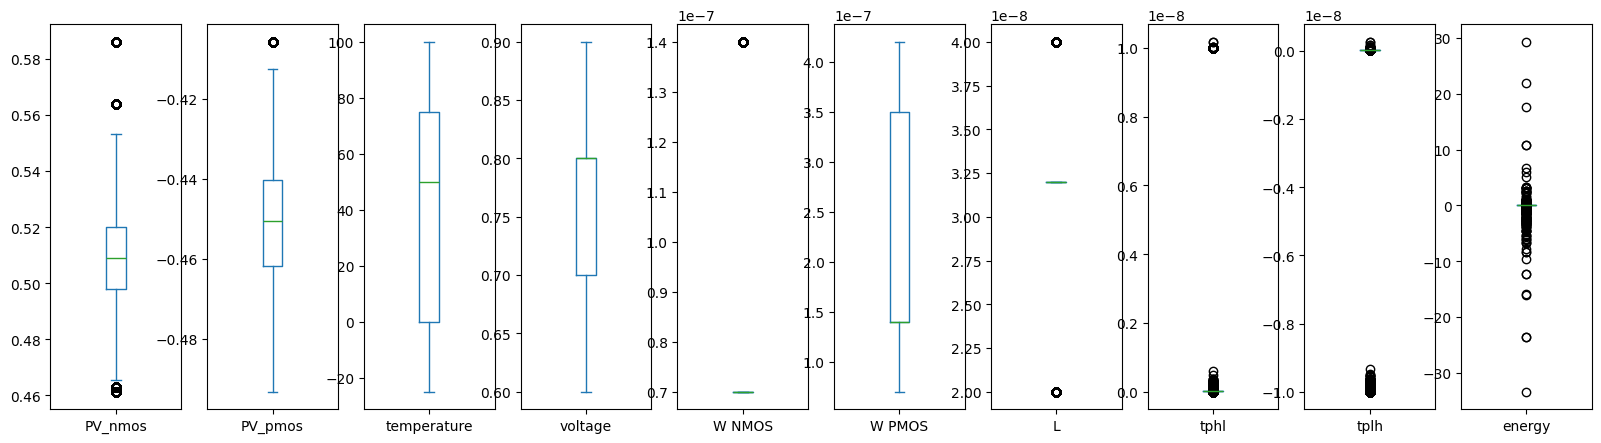

<Figure size 640x480 with 0 Axes>

In [15]:
df.plot(kind='box', figsize=(30, 5), subplots=True, layout=(1, 15))
plt.figure()
plt.show()
plt.close()

## Removing outliers

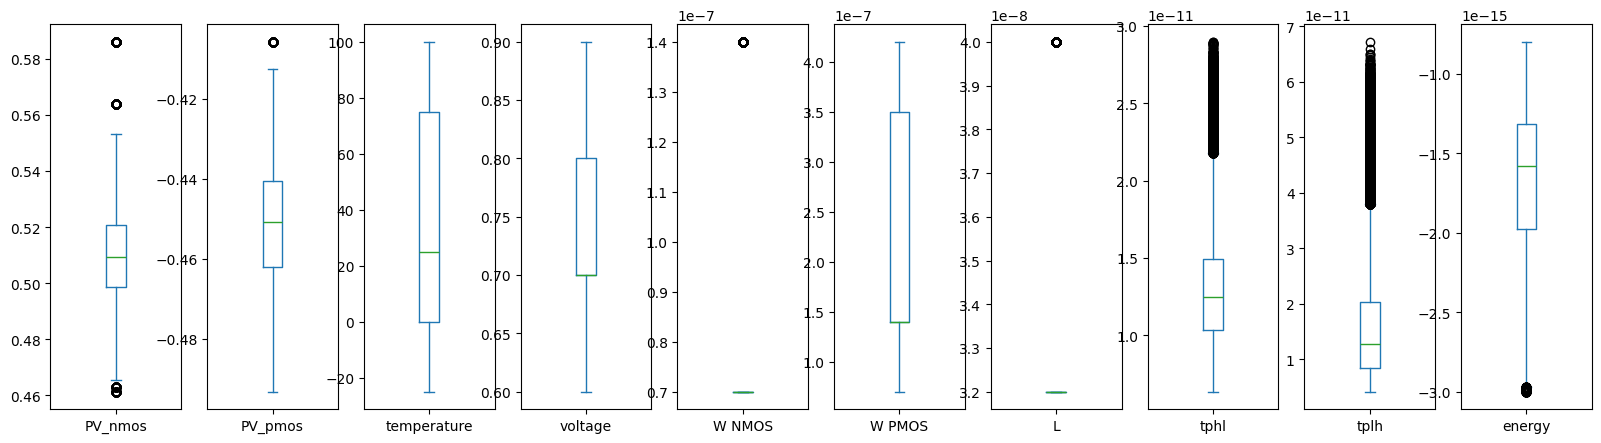

<Figure size 640x480 with 0 Axes>

In [16]:
# Gabriel's code fot removing outliers
df = df[(2e-12<=df.tphl)&(df.tphl<=2.9e-11)]
df = df[(1e-12<=df.tplh)&(df.tplh<=6.8e-11)]
df = df[(-3e-15<=df.energy)]

df.plot(kind='box', figsize=(30, 5), subplots=True, layout=(1, 15))
plt.figure()
plt.show()
plt.close()

In [17]:
df.to_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/01_data_cleaning/cmos_df.csv', index=True)